# 03: Neural SDE Density Forecasting (Single Asset)

## change this introduction
In this notebook, we move away from traditional point predictions (e.g., "Bitcoin will go up 2% tomorrow") and implement **Density Forecasting**. Markets are stochastic, meaning we must predict both the expected direction and the uncertainty.

(We have already moved to this approach)

### The Architecture
1. **The Input Data:** A single asset (e.g., BTC-USD). We use the daily returns.
2. **Feature Extraction:** We take a 30-day rolling window of returns, pair it with a time axis (Time Augmentation), and extract the **Path Signature (Depth 2)**. This gives the Neural Network a deterministic summary of the recent trajectory's geometry.
3. **The Neural SDE:** The Neural Network acts as the drift and diffusion estimator for a Stochastic Differential Equation. 
   * It outputs two values for tomorrow: **$\mu$ (Drift / Expected Return)** and **$\sigma$ (Diffusion / Volatility)**.
4. **The Loss Function:** We train the model using **Negative Log-Likelihood (NLL)**. The model is penalized if the actual return falls outside its predicted distribution, forcing it to increase $\sigma$ when it is uncertain.
5. **Evaluation:** We use a strict Point-in-Time (PIT) walk-forward backtest to prevent data leakage.

In [1]:
import numpy as np
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


# import yfinance as yf
import esig
import torch
import torch.nn as nn
import torch.optim as optim

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
# from src.data.data_loader import fetch_asset_data
# Import your custom metrics pipeline
# (Adjust the import path if metrics.py is located in a different folder, e.g., src.evaluation.metrics)
from src.data.data_loader import fetch_asset_data
from src.evaluation.metrics import evaluate_forecasts, rolling_ks_test, print_evaluation_summary
from src.models.neural_networks import extract_signatures, NeuralSDE_StudentT, anchored_student_t_loss, student_t_nll_loss

warnings.filterwarnings("ignore")

Loaded intel_openmp/libiomp5md.dll from C:\Users\fe_ma\miniconda3\envs\quant-ai-lab-2\Library\bin\libiomp5md.dll


In [2]:
# Fetch real market data
ticker = 'ARKK'

# ticker = 'BTC-USD'

start_date = date(2018, 1, 1)
# start_date = date(2023, 1, 1)
end_date = date(2025, 12, 31)

In [3]:
# Define the major volatility regimes to highlight
volatile_periods = {
    "COVID-19 Crash": ("2020-02-15", "2020-06-01"),
    "2022 Bear Market": ("2022-01-01", "2022-12-31")
}

In [4]:
df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])

df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
df_vix = (df_vix[['prices']] / 100.0) / np.sqrt(252)
df_vix.columns = ['VIX']
df_returns = pd.concat([df[['returns']], df_vix], axis=1)
df_returns.dropna(inplace=True)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [5]:
window_size = 30
signature_depth = 2


In [6]:
X_tensor, y_tensor, valid_dates = extract_signatures(df_returns, window_size, signature_depth)

Extracting Path Signatures...
Feature Matrix Shape: torch.Size([1978, 8])
Target Matrix Shape: torch.Size([1978, 1])


### The Density Predictor (Student's t-Distribution NLL)

Financial returns exhibit **fat tails**, meaning extreme market shocks happen far more frequently than a normal distribution predicts. To account for this, our Neural Network outputs a Student's t-distribution rather than a Gaussian.

The network will now predict **three** parameters for tomorrow:
1. **$\mu$ (Location / Expected Return)** 2. **$\sigma$ (Scale / Core Volatility)**
3. **$\nu$ (Degrees of Freedom / Tail Fatness)** - A lower $\nu$ means fatter tails (higher probability of extreme events).

The loss function is the Student's t Negative Log-Likelihood. Instead of coding the complex Gamma functions by hand, we leverage PyTorch's native distribution classes to calculate the exact log-probability:
$$\text{Loss} = -\log \Big( \text{StudentT}(y \mid \mu, \sigma, \nu) \Big)$$

* **Why this is powerful:** If the Path Signature detects an incoming market shock, the network can lower $\nu$ to "fatten the tails" to absorb the shock safely, without having to unnecessarily blow up the core volatility ($\sigma$).

In [7]:
import scipy.stats as stats

# --- POINT-IN-TIME BACKTESTER ---
initial_train_size = 500  # Train on first 500 days
step_size = 20            # Retrain every 20 days
epochs_per_step = 150

out_of_sample_mu = []
out_of_sample_sigma = []
out_of_sample_nu = []

actual_returns = []
oos_dates = valid_dates[initial_train_size:]

print("Starting Strict Point-in-Time Walk-Forward Backtest...")

for current_t in range(initial_train_size, len(X_tensor), step_size):
    # 1. Strict historical isolation
    X_train = X_tensor[:current_t]
    y_train = y_tensor[:current_t]
    
    # 2. Scale targets to help NN convergence (returns are tiny decimals)
    scale_factor = 100.0
    y_train_scaled = y_train * scale_factor
    
    # ==========================================
    # 3. CALCULATE THE HISTORICAL PRIOR (x_0)
    # ==========================================
    # Fit a standard Student's t to the training window data
    hist_nu, hist_mu, hist_sigma = stats.t.fit(y_train_scaled.numpy().flatten())
    
    # Convert to tensors so they can be used in the PyTorch loss function
    prior_nu_t = torch.tensor(hist_nu, dtype=torch.float32)
    prior_mu_t = torch.tensor(hist_mu, dtype=torch.float32)
    prior_sigma_t = torch.tensor(hist_sigma, dtype=torch.float32)

    # 3. Test Window
    end_test = min(current_t + step_size, len(X_tensor))
    X_test = X_tensor[current_t:end_test]
    y_test = y_tensor[current_t:end_test]
    
    # 4. Train Model
    model = NeuralSDE_StudentT(input_dim=X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    
    for epoch in range(epochs_per_step):
        optimizer.zero_grad()
        mu_pred, sigma_pred, nu_pred = model(X_train)
        
        loss = anchored_student_t_loss(
            mu_pred, sigma_pred, nu_pred, 
            y_train_scaled, 
            prior_mu_t, prior_sigma_t, prior_nu_t, 
            lambda_reg=0.01
            )
        # loss = student_t_nll_loss(mu_pred, sigma_pred, nu_pred, y_train_scaled)

        # mu_pred, sigma_pred = model(X_train)
        # loss = gaussian_nll_loss(mu_pred, sigma_pred, y_train_scaled)
        loss.backward()
        optimizer.step()
        
    # 5. Out-of-Sample Predictions
    with torch.no_grad():
        mu_oos_scaled, sigma_oos_scaled, nu_oos = model(X_test)

        mu_oos = mu_oos_scaled / scale_factor
        sigma_oos = sigma_oos_scaled / scale_factor
        # nu_oos remains untouched

        out_of_sample_mu.extend(mu_oos.numpy().flatten())
        out_of_sample_sigma.extend(sigma_oos.numpy().flatten())
        out_of_sample_nu.extend(nu_oos.numpy().flatten()) # <--- Create a list for this

        # mu_oos_scaled, sigma_oos_scaled = model(X_test)
        
        # # Unscale back to raw return values
        # mu_oos = mu_oos_scaled / scale_factor
        # sigma_oos = sigma_oos_scaled / scale_factor
        
        # out_of_sample_mu.extend(mu_oos.numpy().flatten())
        # out_of_sample_sigma.extend(sigma_oos.numpy().flatten())
        actual_returns.extend(y_test.numpy().flatten())
        
    print(f"Walk-forward complete up to day {end_test} / {len(X_tensor)}")

print("Backtest Complete!")

Starting Strict Point-in-Time Walk-Forward Backtest...
Walk-forward complete up to day 520 / 1978
Walk-forward complete up to day 540 / 1978
Walk-forward complete up to day 560 / 1978
Walk-forward complete up to day 580 / 1978
Walk-forward complete up to day 600 / 1978
Walk-forward complete up to day 620 / 1978
Walk-forward complete up to day 640 / 1978
Walk-forward complete up to day 660 / 1978
Walk-forward complete up to day 680 / 1978
Walk-forward complete up to day 700 / 1978
Walk-forward complete up to day 720 / 1978
Walk-forward complete up to day 740 / 1978
Walk-forward complete up to day 760 / 1978
Walk-forward complete up to day 780 / 1978
Walk-forward complete up to day 800 / 1978
Walk-forward complete up to day 820 / 1978
Walk-forward complete up to day 840 / 1978
Walk-forward complete up to day 860 / 1978
Walk-forward complete up to day 880 / 1978
Walk-forward complete up to day 900 / 1978
Walk-forward complete up to day 920 / 1978
Walk-forward complete up to day 940 / 1978

### 3. Quantitative Evaluation (Rolling K-S Test)

Visualizing the confidence intervals is helpful, but we need statistical proof that our predicted distributions match the realized market returns. 

We use the external `metrics.py` pipeline to calculate the **Probability Integral Transform (PIT)**. If our model is perfectly calibrated, the PIT values should form a uniform distribution. We use a **Rolling Kolmogorov-Smirnov (K-S) Test** to verify this uniformity over a sliding 60-day window. If the p-value drops below 0.05, it means the SDE has locally lost calibration and is predicting the wrong distribution.

Because `metrics.py` expects discrete samples, we simulate 1,000 Monte Carlo draws from our predicted $\mu$ and $\sigma$ for each day.

In [8]:
import scipy.stats as stats

# ==========================================
# 1. GENERATE MONTE CARLO ENSEMBLES
# ==========================================
# Convert the lists to arrays
mu_arr = np.array(out_of_sample_mu)
sigma_arr = np.array(out_of_sample_sigma)
nu_arr = np.array(out_of_sample_nu)

actual_arr = np.array(actual_returns)

# Generate 1000 samples per day using the predicted Student's t parameters
n_samples = 1000
predicted_ensembles = np.zeros((len(mu_arr), n_samples))

for i in range(len(mu_arr)):
    # scipy.stats.t.rvs takes (df, loc, scale, size)
    predicted_ensembles[i, :] = stats.t.rvs(
        df=nu_arr[i], 
        loc=mu_arr[i], 
        scale=sigma_arr[i], 
        size=n_samples
    )


# # Our SDE gave us mu and sigma. We generate 1000 samples per day to feed metrics.py
# n_samples = 1000
# predicted_ensembles = np.random.normal(
#     loc=mu_arr.reshape(-1, 1), 
#     scale=sigma_arr.reshape(-1, 1), 
#     size=(len(mu_arr), n_samples)
# )

# Convert actual returns to a Pandas Series with proper dates
actual_series = pd.Series(actual_arr, index=oos_dates)

# ==========================================
# 2. RUN THE METRICS PIPELINE
# ==========================================
print("Evaluating Forecasts (PIT, CRPS, Log-Likelihood)...")
df_eval = evaluate_forecasts(actual_series, predicted_ensembles)

# Print the overall summary
print_evaluation_summary(df_eval, ticker_name=ticker)

# Run the Rolling KS Test (60-day window)
print("Running Rolling K-S Test (Window = 60 days)...")
rolling_p_values = rolling_ks_test(df_eval['PIT'], window=60)


# # ==========================================
# # 3. VISUALIZE THE ROLLING CALIBRATION
# # ==========================================
# sns.set_theme(style="darkgrid")
# plt.figure(figsize=(14, 5))

# # Plot the p-values
# plt.plot(rolling_p_values.index, rolling_p_values.values, color='purple', linewidth=2, label="K-S p-value")

# # The critical threshold (alpha = 0.05)
# plt.axhline(0.05, color='red', linestyle='--', linewidth=2, label="Significance Threshold (α = 0.05)")

# # Shade the areas where the model fails calibration
# plt.fill_between(
#     rolling_p_values.index, 
#     0, 0.05, 
#     where=(rolling_p_values.values < 0.05), 
#     color='red', alpha=0.3, label="Miscalibrated Periods"
# )

# plt.title(f"Rolling K-S Uniformity Test (60-Day Window) - {ticker}", fontweight='bold', fontsize=14)
# plt.ylabel("p-value")
# plt.xlabel("Date")
# plt.ylim(0, 1.05)
# plt.legend(loc="upper left")
# plt.tight_layout()
# plt.show()

Evaluating Forecasts (PIT, CRPS, Log-Likelihood)...

--- ARKK EVALUATION SUMMARY ---
Average CRPS:           0.01510 (Lower is better)
Total Log-Likelihood:   3014.73
Average Log-Likelihood: 2.03974
Running Rolling K-S Test (Window = 60 days)...


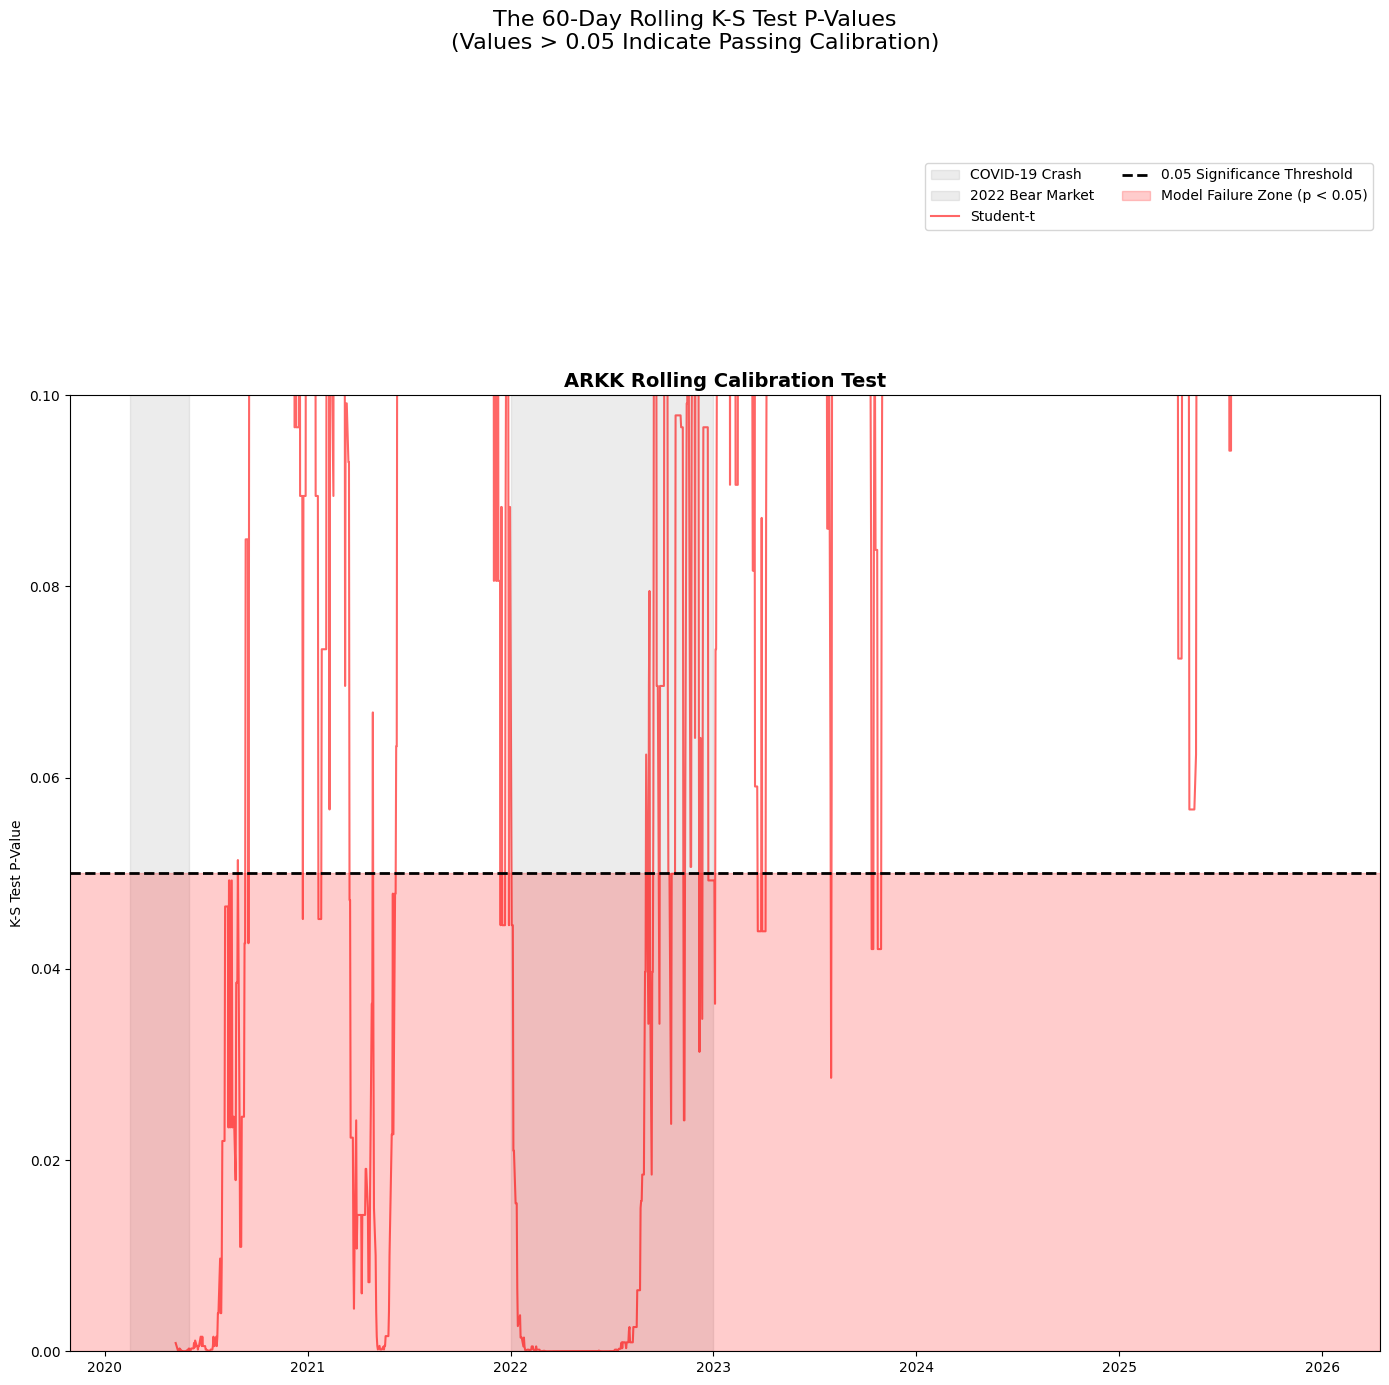

In [9]:
import matplotlib.pyplot as plt

from src.evaluation.metrics import rolling_ks_test
from src.evaluation.plotting import plot_rolling_ks

# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval['PIT'], window=60)

pvals = [{'name': 'Student-t', 'values': rolling_p_values, 'color': 'red'}]

fig, ax = plt.subplots(1, 1, figsize=(14, 15), sharex=False)
fig.suptitle("The 60-Day Rolling K-S Test P-Values\n(Values > 0.05 Indicate Passing Calibration)", fontsize=16, y=0.92)
plot_rolling_ks(ax, ticker, volatile_periods, pvals)
ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1.0, 1.25), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

In [10]:
from src.evaluation.metrics import block_ks_test
block_ks_test(df_eval['PIT'], block_size=22 * 3)


--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 22
Blocks Failed (p < 0.05): 8
True Failure Rate:        36.4%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2020-02-12,2020-05-15,0.259091,0.000214,❌ FAILED
1,2020-05-18,2020-08-19,0.189848,0.014776,❌ FAILED
2,2020-08-20,2020-11-20,0.115091,0.321280,✅ PASSED
3,2020-11-23,2021-03-01,0.124879,0.234439,✅ PASSED
4,2021-03-02,2021-06-03,0.220303,0.002710,❌ FAILED
5,2021-06-04,2021-09-07,0.061848,0.948809,✅ PASSED
6,2021-09-08,2021-12-09,0.162182,0.055221,✅ PASSED
7,2021-12-10,2022-03-16,0.325000,0.000001,❌ FAILED
8,2022-03-17,2022-06-21,0.312091,0.000003,❌ FAILED
9,2022-06-22,2022-09-23,0.179485,0.024816,❌ FAILED
